# Imports

In [ ]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [ ]:
from sklearn.metrics import r2_score


# Preprocessing and Visualization

In [ ]:
df = pd.read_csv('/content/training.csv')
df

#############################################

df2 = pd.read_csv('/content/scoring.csv')
df2

,Date,Vehicle Category,GVWR Class,Fuel Type,Model Year,Fuel Technology,Electric Mile Range,Number of Vehicles Registered at the Same Address,Region,Vehicle Population
0,2024,P,Not Applicable,Gasoline,2020.0,ICE,Not Applicable,≥4,Statewide,316065
1,2024,P,Not Applicable,Gasoline,2021.0,ICE,Not Applicable,≥4,Statewide,315986
2,2024,P,Not Applicable,Gasoline,2022.0,ICE,Not Applicable,≥4,Statewide,306487
3,2024,P,Not Applicable,Gasoline,2024.0,ICE,Not Applicable,≥4,Statewide,284754
4,2024,P,Not Applicable,Gasoline,2023.0,ICE,Not Applicable,≥4,Statewide,284153
...,...,...,...,...,...,...,...,...,...,...
7541,2024,B,Not Applicable,Diesel,1989.0,ICE,Not Applicable,3,Statewide,1
7542,2024,B,Not Applicable,Diesel,1988.0,ICE,Not Applicable,2,Statewide,1
7543,2024,B,Not Applicable,Diesel,1988.0,ICE,Not Applicable,3,Statewide,1
7544,2024,B,Not Applicable,Diesel,1987.0,ICE,Not Applicable,2,Statewide,1


In [ ]:
df.tail(30000)

,Date,Vehicle Category,GVWR Class,Fuel Type,Model Year,Fuel Technology,Electric Mile Range,Number of Vehicles Registered at the Same Address,Region,Vehicle Population
11053,2023,MH,Not Applicable,Gasoline,1997.0,ICE,Not Applicable,2,Statewide,328
11054,2023,B,Not Applicable,Gasoline,2006.0,ICE,Not Applicable,≥4,Statewide,328
11055,2023,T6,5,Diesel,2017.0,ICE,Not Applicable,1,Statewide,328
11056,2023,T4,2,Diesel,1995.0,ICE,Not Applicable,3,Statewide,328
11057,2023,T3,2,Diesel,2012.0,ICE,Not Applicable,3,Statewide,328
...,...,...,...,...,...,...,...,...,...,...
41048,2019,B,Not Applicable,Diesel,1983.0,ICE,Not Applicable,1,Statewide,1
41049,2019,B,Not Applicable,Diesel,1980.0,ICE,Not Applicable,2,Statewide,1
41050,2019,B,Not Applicable,Diesel,1978.0,ICE,Not Applicable,3,Statewide,1
41051,2019,B,Not Applicable,Diesel,1976.0,ICE,Not Applicable,2,Statewide,1


In [ ]:

# Remove the inequality from NOVRATSA
df['Number of Vehicles Registered at the Same Address'] = df['Number of Vehicles Registered at the Same Address'].astype(str).str.replace(r'[<>=]', '', regex=True)
print(df['Number of Vehicles Registered at the Same Address'])
# Convert the column to numeric, coercing errors to NaN
df['Number of Vehicles Registered at the Same Address'] = pd.to_numeric(df['Number of Vehicles Registered at the Same Address'], errors='coerce')

##########################################################

df2['Number of Vehicles Registered at the Same Address'] = df2['Number of Vehicles Registered at the Same Address'].astype(str).str.replace(r'[<>=]', '', regex=True)
print(df2['Number of Vehicles Registered at the Same Address'])
df2['Number of Vehicles Registered at the Same Address'] = pd.to_numeric(df2['Number of Vehicles Registered at the Same Address'], errors='coerce')

print(df['Number of Vehicles Registered at the Same Address'])


0        4.0
1        1.0
2        1.0
3        4.0
4        4.0
        ... 
41048    1.0
41049    2.0
41050    3.0
41051    2.0
41052    3.0
Name: Number of Vehicles Registered at the Same Address, Length: 41053, dtype: object
0       4.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
7541    3.0
7542    2.0
7543    3.0
7544    2.0
7545    1.0
Name: Number of Vehicles Registered at the Same Address, Length: 7546, dtype: object
0        4.0
1        1.0
2        1.0
3        4.0
4        4.0
        ... 
41048    1.0
41049    2.0
41050    3.0
41051    2.0
41052    3.0
Name: Number of Vehicles Registered at the Same Address, Length: 41053, dtype: float64


In [ ]:
# Find indices of NaN values in the specified column
nan_indices = df[df['Number of Vehicles Registered at the Same Address'].isnull()].index

nan_indices

# Get indices where 'Number of Vehicles Registered at the Same Address' is NOT NaN
not_nan_indices = df[~df['Number of Vehicles Registered at the Same Address'].isnull()].index
not_nan_indices

######################################################

nan_indices2 = df2[df2['Number of Vehicles Registered at the Same Address'].isnull()].index

nan_indices2

not_nan_indices2 = df2[~df2['Number of Vehicles Registered at the Same Address'].isnull()].index
not_nan_indices2

Index([   7,    8,   10,   12,   13,   14,   16,   18,   19,   20,
       ...
       7536, 7537, 7538, 7539, 7540, 7541, 7542, 7543, 7544, 7545],
      dtype='int64', length=5278)

In [ ]:
df['Number of Vehicles Registered at the Same Address'].iloc[nan_indices] = 4

###################################################################

df2['Number of Vehicles Registered at the Same Address'].iloc[nan_indices2] = 4
#df['Number of Vehicles Registered at the Same Address'].iloc[nan_indices]

<ipython-input-62-656b015c7a1e>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Number of Vehicles Registered at the Same Address'].iloc[nan_indices] = 4
<ipython-input-62-656b015c7a1e>:1: SettingWithCopyWarning: 
A value is trying to b

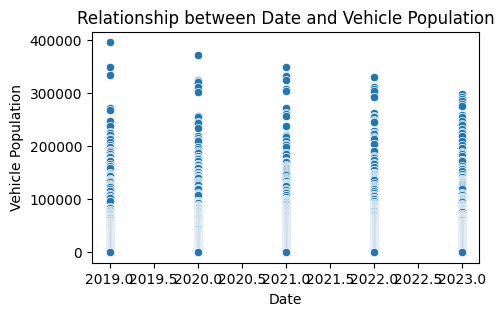

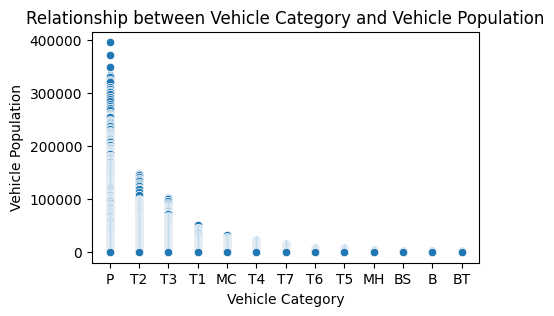

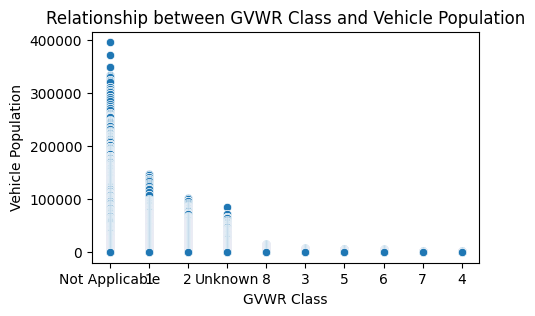

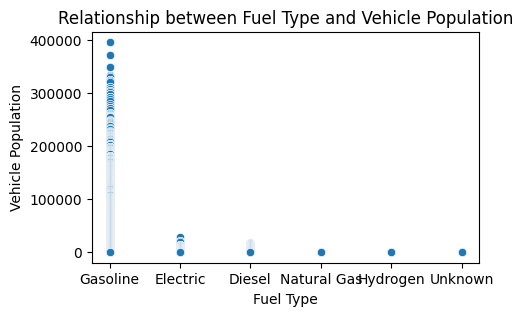

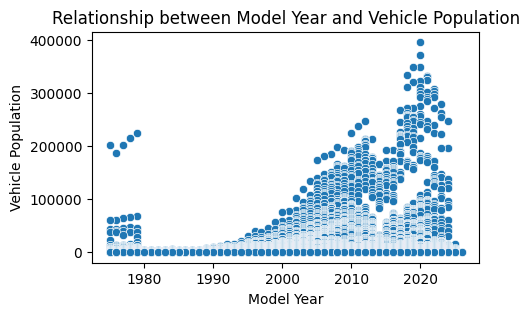

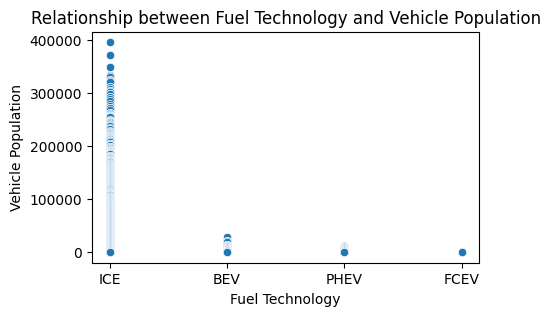

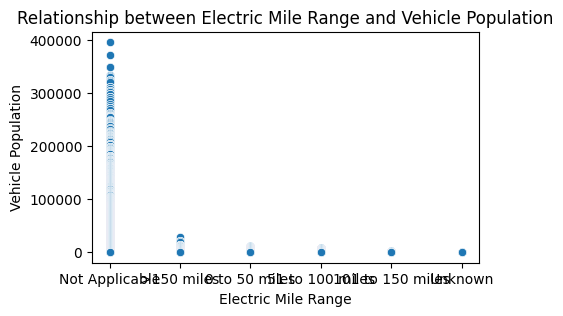

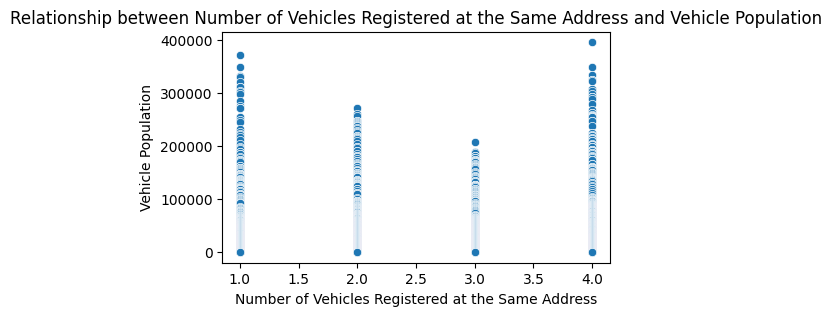

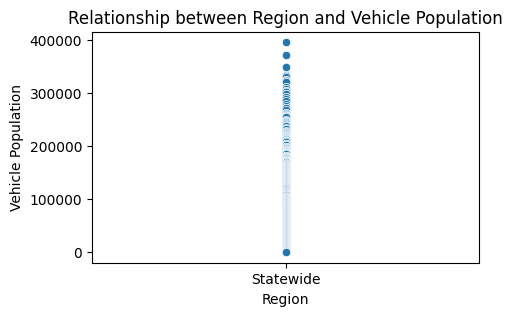

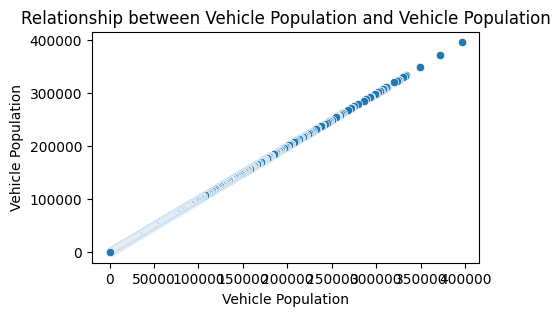

In [ ]:
# Observation of features vs target variable to verify a linear realationship
for col in df.columns:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[col], y= df['Vehicle Population'])
    plt.title(f'Relationship between {col} and Vehicle Population')
    #plt.savefig(col)
    plt.show()


# Data Cleaning and Analysis

In [ ]:
# Check the number of unique values in each column

for column in df.columns:
  unique_count = df[column].nunique()
  print(f"Column '{column}' has {unique_count} unique values.")


Column 'Date' has 5 unique values.
Column 'Vehicle Category' has 13 unique values.
Column 'GVWR Class' has 10 unique values.
Column 'Fuel Type' has 6 unique values.
Column 'Model Year' has 52 unique values.
Column 'Fuel Technology' has 4 unique values.
Column 'Electric Mile Range' has 6 unique values.
Column 'Number of Vehicles Registered at the Same Address' has 4 unique values.
Column 'Region' has 1 unique values.
Column 'Vehicle Population' has 6232 unique values.


In [ ]:
# prompt: show me all the unique values in the column date

print(df['Date'].unique())


[2019 2020 2021 2022 2023]


In [ ]:
print(df['Model Year'].unique())


[2020. 2019. 2018. 2021. 2022. 2023. 2017. 2024. 2012. 2011. 1979. 2010.
 1978. 2013. 1977. 1975. 2008. 2009. 2016. 2015. 1976. 2007. 2006. 2005.
 2014. 2004. 2003. 2002. 2001. 2000. 1999. 1998. 1996. 1997. 1995.   nan
 1994. 1993. 2025. 1992. 1991. 1990. 1989. 1984. 1980. 1983. 1981. 1988.
 1982. 1987. 1986. 1985. 2026.]


In [ ]:
# Converts nan value in Model Year to median
median_model_year = df['Model Year'].median()
df['Model Year'] = df['Model Year'].fillna(median_model_year)
print(df['Model Year'].unique())

###########################################

median_model_year2 = df2['Model Year'].median()
df2['Model Year'] = df2['Model Year'].fillna(median_model_year2)
print(df2['Model Year'].unique())

[2020. 2019. 2018. 2021. 2022. 2023. 2017. 2024. 2012. 2011. 1979. 2010.
 1978. 2013. 1977. 1975. 2008. 2009. 2016. 2015. 1976. 2007. 2006. 2005.
 2014. 2004. 2003. 2002. 2001. 2000. 1999. 1998. 1996. 1997. 1995. 1994.
 1993. 2025. 1992. 1991. 1990. 1989. 1984. 1980. 1983. 1981. 1988. 1982.
 1987. 1986. 1985. 2026.]
[2020. 2021. 2022. 2024. 2023. 2018. 2019. 1980. 2017. 2025. 2012. 2011.
 2013. 2010. 2016. 2015. 2014. 2009. 2008. 2007. 2006. 2005. 2004. 2003.
 2002. 2001. 2000. 1999. 1998. 1996. 1997. 1995. 1994. 1992. 1993. 1991.
 1990. 1989. 2026. 1984. 1983. 1981. 1982. 1988. 1986. 1987. 1985.]


In [ ]:
#Drop region column
df = df.drop(columns=['Region'])

df2 = df2.drop(columns=['Region'])

In [ ]:
# prompt: replace 'Unknown' with median values in 'GVWR Class', 'Electric Mile Range', 'Fuel Type'

# Replace 'Unknown' with median values for specified columns

for col in ['GVWR Class', 'Electric Mile Range', 'Fuel Type']:
    # Calculate the median for the current column, excluding 'Unknown' values
    median_value = df[df[col] != 'Unknown'][col].mode()[0]

    # Replace 'Unknown' values with the calculated median
    df[col] = df[col].replace('Unknown', median_value)

# Repeat the same process for the df2 DataFrame
for col in ['GVWR Class', 'Electric Mile Range', 'Fuel Type']:
    median_value = df2[df2[col] != 'Unknown'][col].mode()[0]
    df2[col] = df2[col].replace('Unknown', median_value)


In [ ]:
df

,Date,Vehicle Category,GVWR Class,Fuel Type,Model Year,Fuel Technology,Electric Mile Range,Number of Vehicles Registered at the Same Address,Vehicle Population
0,2019,P,Not Applicable,Gasoline,2020.0,ICE,Not Applicable,4.0,395883
1,2020,P,Not Applicable,Gasoline,2020.0,ICE,Not Applicable,1.0,370954
2,2021,P,Not Applicable,Gasoline,2020.0,ICE,Not Applicable,1.0,349406
3,2019,P,Not Applicable,Gasoline,2019.0,ICE,Not Applicable,4.0,348475
4,2019,P,Not Applicable,Gasoline,2018.0,ICE,Not Applicable,4.0,333296
...,...,...,...,...,...,...,...,...,...
41048,2019,B,Not Applicable,Diesel,1983.0,ICE,Not Applicable,1.0,1
41049,2019,B,Not Applicable,Diesel,1980.0,ICE,Not Applicable,2.0,1
41050,2019,B,Not Applicable,Diesel,1978.0,ICE,Not Applicable,3.0,1
41051,2019,B,Not Applicable,Diesel,1976.0,ICE,Not Applicable,2.0,1


In [ ]:
print(df['Electric Mile Range'].unique())


['Not Applicable' '>150 miles' '0 to 50 miles' '51 to 100 miles'
 '101 to 150 miles']


In [ ]:
print(df['Fuel Technology'].unique())


['ICE' 'BEV' 'PHEV' 'FCEV']


In [ ]:
print(df['Fuel Type'].unique())

['Gasoline' 'Electric' 'Diesel' 'Natural Gas' 'Hydrogen']


In [ ]:
print(df['GVWR Class'].unique())

['Not Applicable' '1' '2' '8' '3' '5' '6' '7' '4']


In [ ]:
print(df['Vehicle Category'].unique())

['P' 'T2' 'T3' 'T1' 'MC' 'T4' 'T7' 'T6' 'T5' 'MH' 'BS' 'B' 'BT']


In [ ]:

print(df['Date'].unique())


[2019 2020 2021 2022 2023]


# Seperating Data

In [ ]:
numerical_df = df.select_dtypes(exclude=['object']).drop(columns=['Vehicle Population'], errors='ignore')
categorical_df = df.select_dtypes(include=['object'])

#####################################################

numerical_df2 = df2.select_dtypes(exclude=['object']).drop(columns=['Vehicle Population'], errors='ignore')
categorical_df2 = df2.select_dtypes(include=['object'])
# replicate this process using the scoring.csv file

In [ ]:
categorical_encoded = pd.get_dummies(categorical_df, drop_first=True)
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = pd.DataFrame(encoder.fit_transform(categorical_df))
categorical_encoded.columns = encoder.get_feature_names_out()

##################################################

categorical_encoded2 = pd.get_dummies(categorical_df2, drop_first=True)
encoder2 = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded2 = pd.DataFrame(encoder2.fit_transform(categorical_df2))
categorical_encoded2.columns = encoder2.get_feature_names_out()

In [ ]:
X = pd.concat([numerical_df, categorical_encoded], axis=1)

###################################################

X2 = pd.concat([numerical_df2, categorical_encoded2], axis=1)

In [ ]:
y = df['Vehicle Population']


y2 = df2['Vehicle Population']


# Model Creation

In [ ]:
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

RandomForestRegressor()

In [ ]:
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

y_pred_rf = rf_model.predict(X)
mse_rf = mean_squared_error(y, y_pred_rf)
r2_rf = r2_score(y, y_pred_rf)

print(f"Random Forest - Root Mean Squared Error: {np.sqrt(mse_rf)}")
print(f"Random Forest - R² Score: {r2_rf}")

Random Forest - Root Mean Squared Error: 3176.5914229804666
Random Forest - R² Score: 0.9715517486895332


In [ ]:
len(y_pred_rf)

41053

In [ ]:
y_pred_rf = rf_model.predict(X2)
mse_rf = mean_squared_error(y2, y_pred_rf)
r2_rf = r2_score(y2, y_pred_rf)

print(f"Random Forest - Root Mean Squared Error: {np.sqrt(mse_rf)}")
print(f"Random Forest - R² Score: {r2_rf}")

Random Forest - Root Mean Squared Error: 5976.239819129678
Random Forest - R² Score: 0.9057495194412186


In [ ]:
# Create a DataFrame from y_pred_rf
y_pred_rf_df = pd.DataFrame({'predicted_vehicle_population': y_pred_rf})

# Save the DataFrame to a CSV file
y_pred_rf_df.to_csv('y_pred_rf.csv', index=False)
